In [2]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [9]:
import sys
sys.path.append("..") 
from processing import  load_UCI_dataset, train_cnn_lstm_baseline, plot_loss_vs_epoch, train_multiscale_cnn_lstm, train_cnn_lstm_attention, evaluate_cnn_lstm_vitaldb

In [4]:
WINDOW_SIZE = 625
STEP_SIZE = 312

BASE_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/5sec_50%overlap/vitaldb_checkpoints"

X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset(
    WINDOW_SIZE=WINDOW_SIZE,
    STEP_SIZE=STEP_SIZE
)

Total recordings: 12000
Train recordings: 9600
Validation recordings: 1200
Test recordings: 1200


100%|██████████| 9600/9600 [02:38<00:00, 60.51it/s]


Skipped recordings: 81


100%|██████████| 1200/1200 [00:20<00:00, 57.63it/s]


Skipped recordings: 7


100%|██████████| 1200/1200 [00:20<00:00, 57.65it/s]


Skipped recordings: 9


In [5]:
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

X_train shape: (829483, 1, 625), y_train shape: (829483, 2)
X_val shape: (104736, 1, 625), y_val shape: (104736, 2)


Device: cuda
X_train: torch.Size([829483, 1, 625])
y_train: torch.Size([829483, 2])
X_val: torch.Size([104736, 1, 625])
y_val: torch.Size([104736, 2])
X_test: torch.Size([105176, 1, 625])
y_test: torch.Size([105176, 2])
Epoch 01/50 | Train Loss: 598.3310 | Val Loss: 231.6967 | Train SBP RMSE: 30.829 | Train DBP RMSE: 15.693 | Val SBP RMSE: 19.004 | Val DBP RMSE: 10.112 | LR: 1.00e-03
Epoch 02/50 | Train Loss: 197.0989 | Val Loss: 198.5022 | Train SBP RMSE: 17.487 | Train DBP RMSE: 9.402 | Val SBP RMSE: 17.589 | Val DBP RMSE: 9.361 | LR: 1.00e-03
Epoch 03/50 | Train Loss: 167.7234 | Val Loss: 181.6717 | Train SBP RMSE: 16.016 | Train DBP RMSE: 8.884 | Val SBP RMSE: 16.798 | Val DBP RMSE: 9.010 | LR: 1.00e-03
Epoch 04/50 | Train Loss: 148.3031 | Val Loss: 182.2349 | Train SBP RMSE: 14.933 | Train DBP RMSE: 8.580 | Val SBP RMSE: 16.823 | Val DBP RMSE: 9.026 | LR: 1.00e-03
Epoch 05/50 | Train Loss: 135.8781 | Val Loss: 164.6973 | Train SBP RMSE: 14.210 | Train DBP RMSE: 8.357 | Val SBP RMS

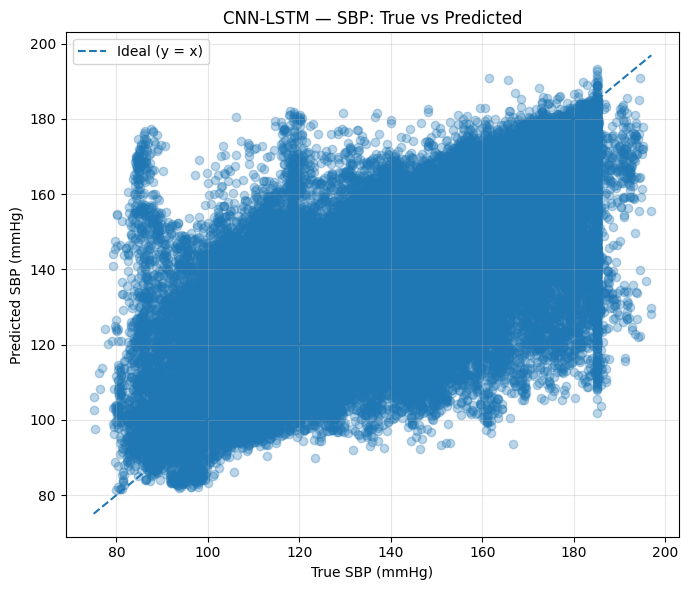

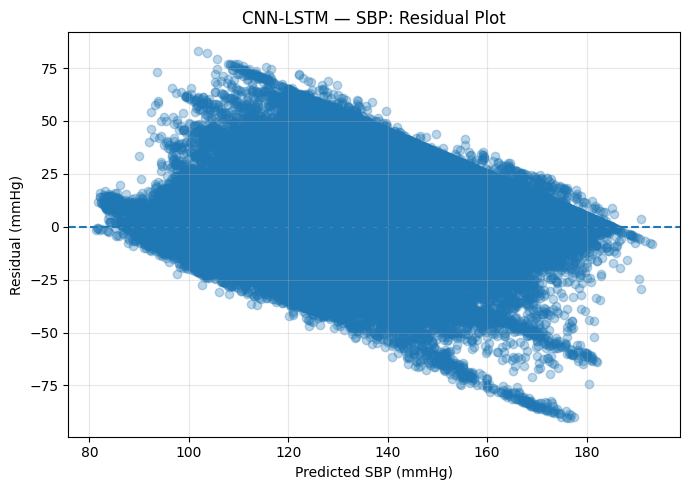

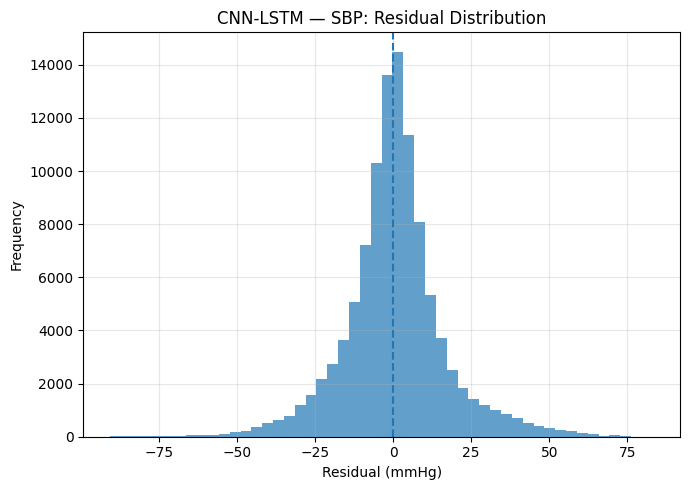

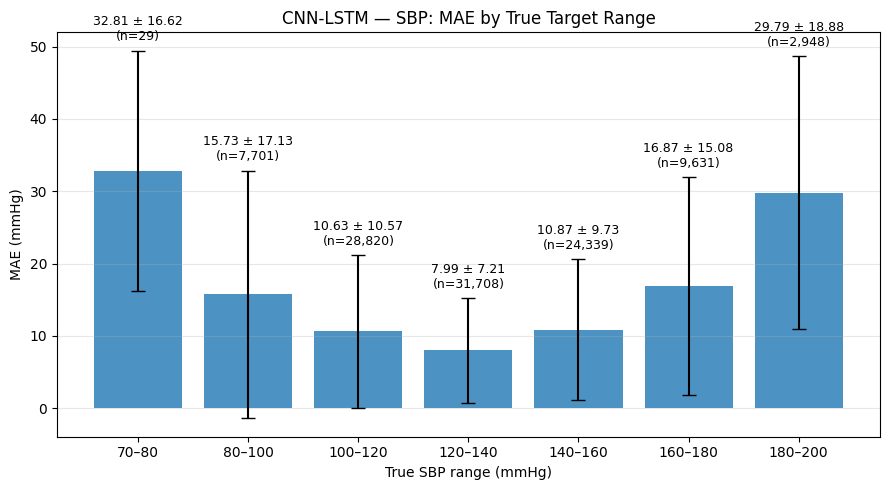

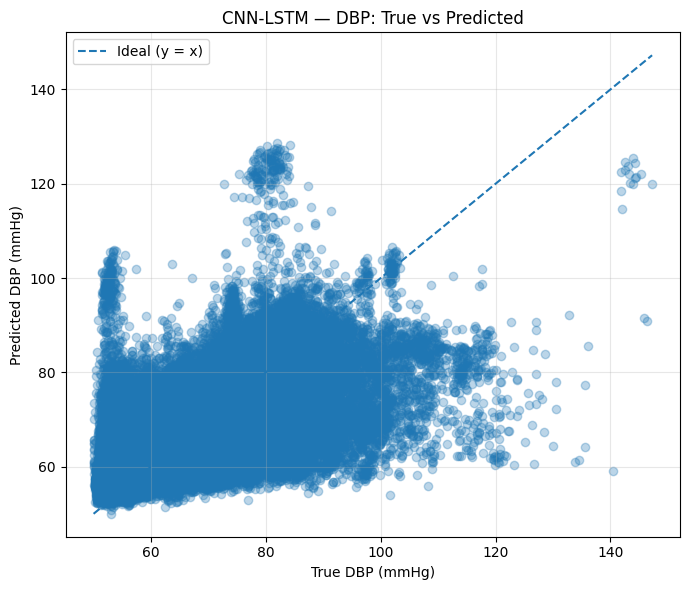

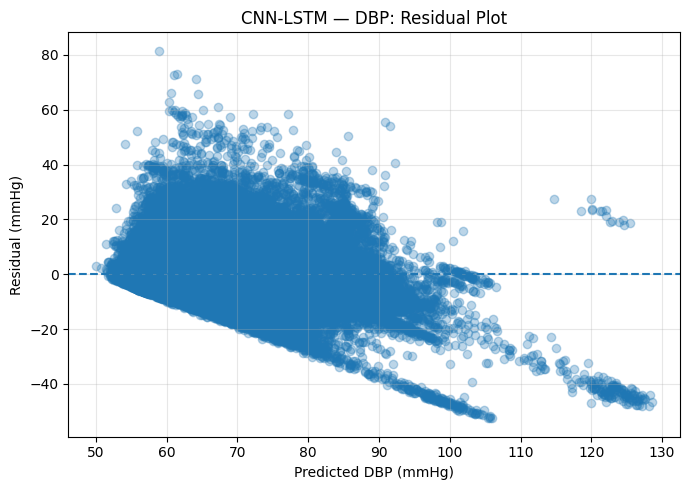

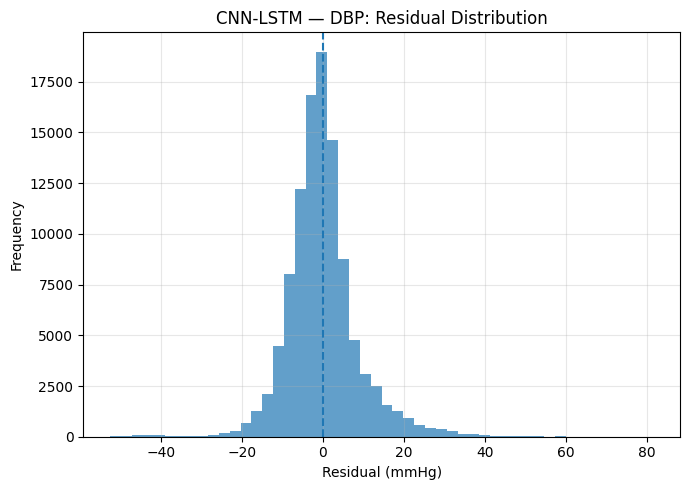

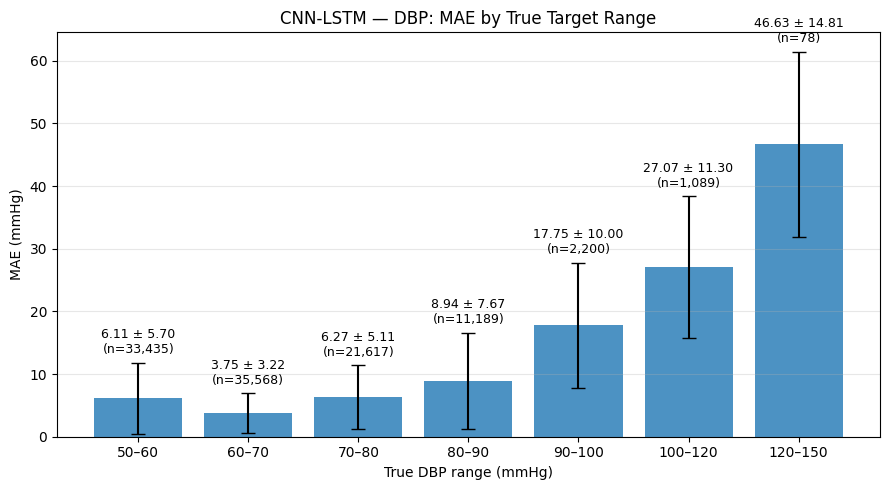

In [6]:
model_cnn_lstm, results_cnn_lstm = train_cnn_lstm_baseline(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    batch_size=256,
    epochs=50,
    lr=1e-3,
    patience=10
)

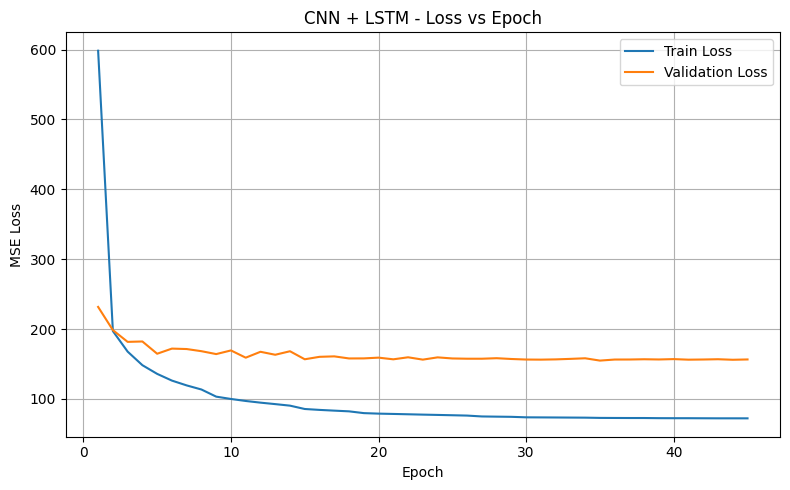

In [7]:
plot_loss_vs_epoch(
    results_cnn_lstm["history"],
    model_name="CNN + LSTM"
)

Number of VitalDB cases: 1963


CNN-LSTM VitalDB prediction: 100%|██████████| 1963/1963 [04:15<00:00,  7.69case/s]



CNN-LSTM
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 25.2499
MSE : 637.5589
R²  : -0.4917
MAE : 19.9191

DBP
RMSE: 14.4583
MSE : 209.0412
R²  : -0.2871
MAE : 11.3542


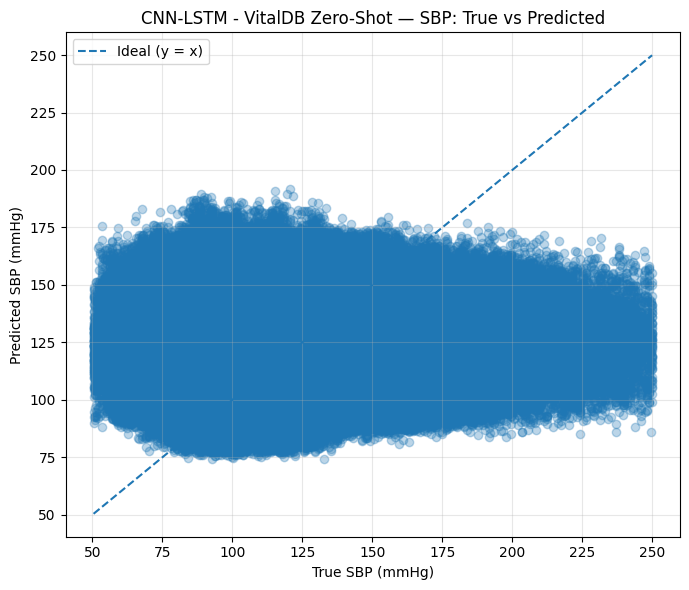

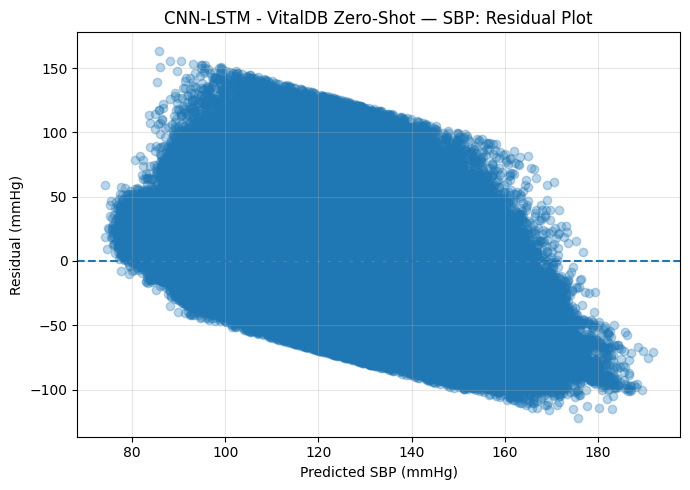

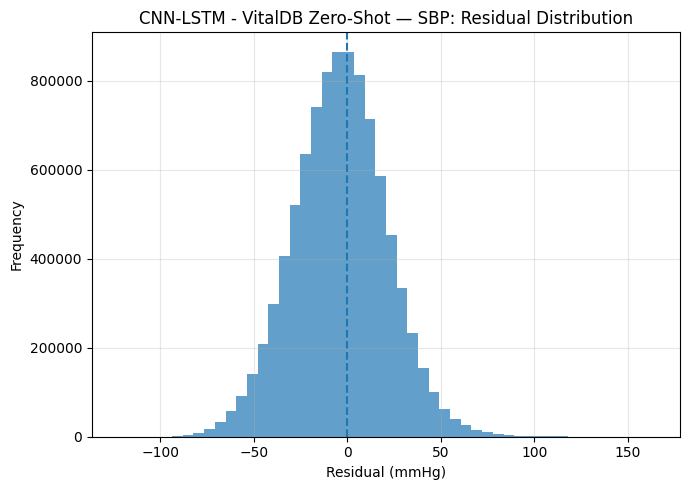

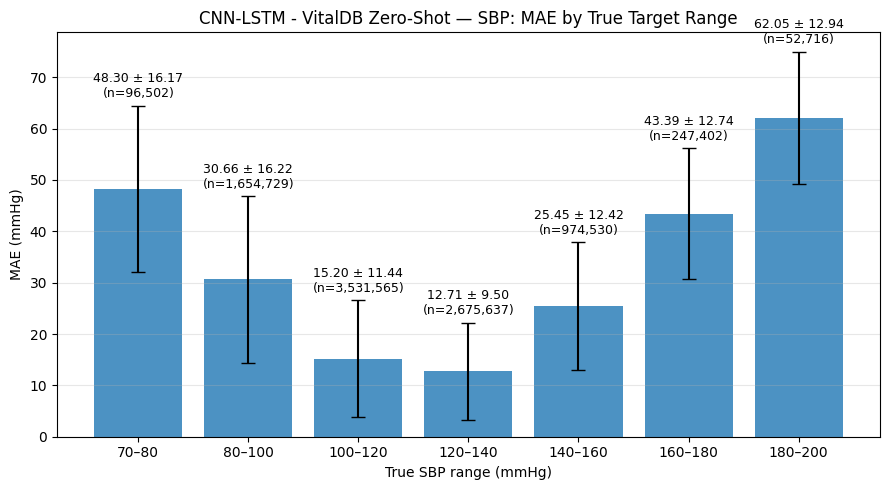

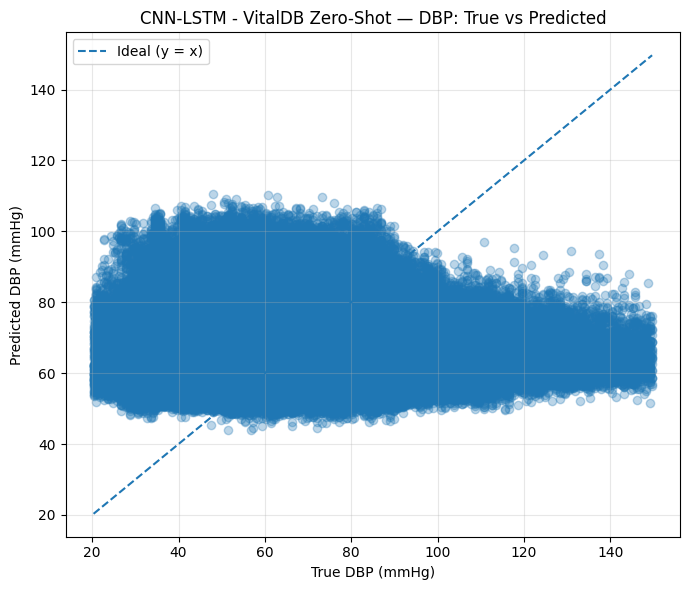

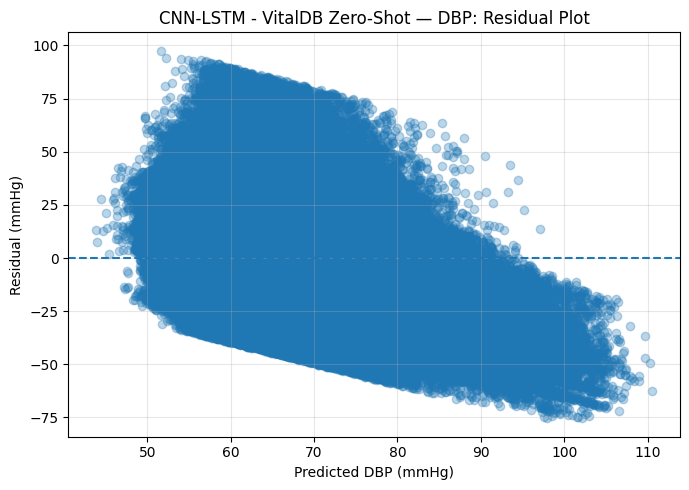

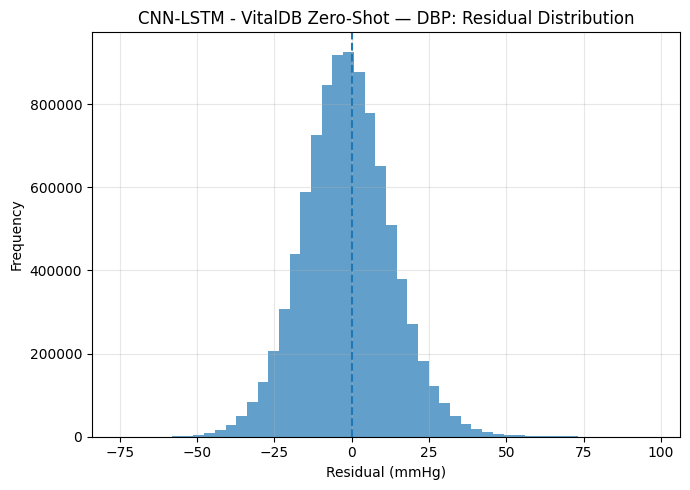

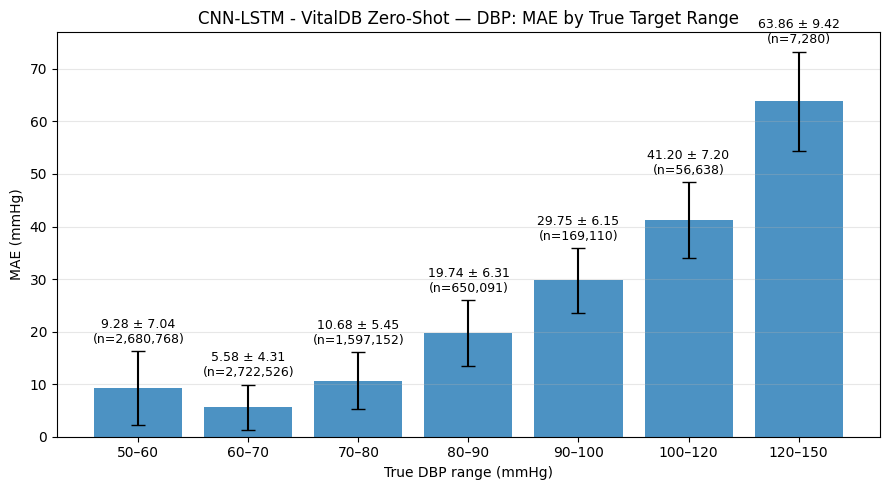

In [14]:
results_cnn_lstm_vitaldb = evaluate_cnn_lstm_vitaldb( model=model_cnn_lstm, base_dir=BASE_DIR, batch_size=256 )

####

Device: cuda
X_train: torch.Size([829483, 1, 625])
y_train: torch.Size([829483, 2])
X_val: torch.Size([104736, 1, 625])
y_val: torch.Size([104736, 2])
X_test: torch.Size([105176, 1, 625])
y_test: torch.Size([105176, 2])
Epoch 01/50 | Train Loss: 570.4243 | Val Loss: 210.6499 | Train SBP RMSE: 30.112 | Train DBP RMSE: 15.300 | Val SBP RMSE: 17.980 | Val DBP RMSE: 9.900 | LR: 1.00e-03
Epoch 02/50 | Train Loss: 182.0889 | Val Loss: 187.7136 | Train SBP RMSE: 16.678 | Train DBP RMSE: 9.275 | Val SBP RMSE: 17.120 | Val DBP RMSE: 9.074 | LR: 1.00e-03
Epoch 03/50 | Train Loss: 155.9455 | Val Loss: 175.1313 | Train SBP RMSE: 15.361 | Train DBP RMSE: 8.715 | Val SBP RMSE: 16.440 | Val DBP RMSE: 8.944 | LR: 1.00e-03
Epoch 04/50 | Train Loss: 137.7952 | Val Loss: 168.4683 | Train SBP RMSE: 14.329 | Train DBP RMSE: 8.383 | Val SBP RMSE: 16.085 | Val DBP RMSE: 8.843 | LR: 1.00e-03
Epoch 05/50 | Train Loss: 126.0833 | Val Loss: 167.1897 | Train SBP RMSE: 13.627 | Train DBP RMSE: 8.153 | Val SBP RMSE

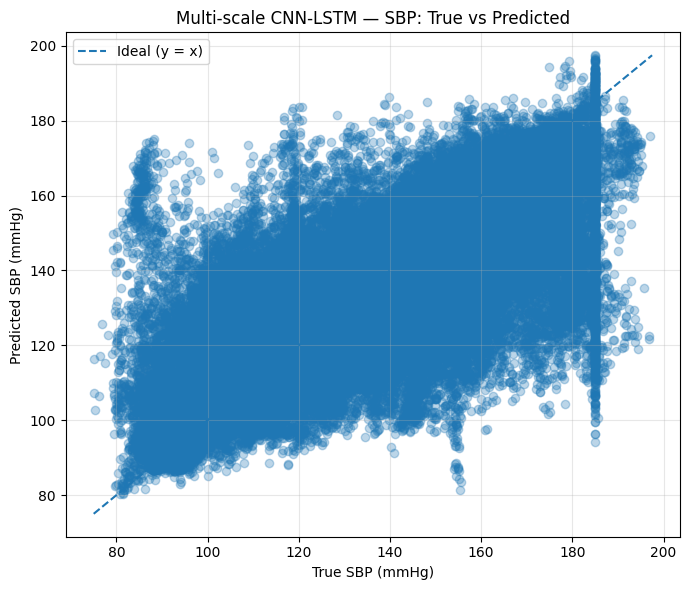

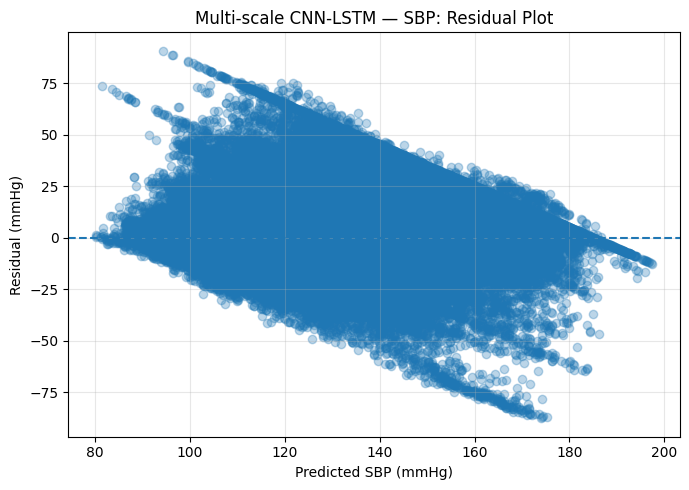

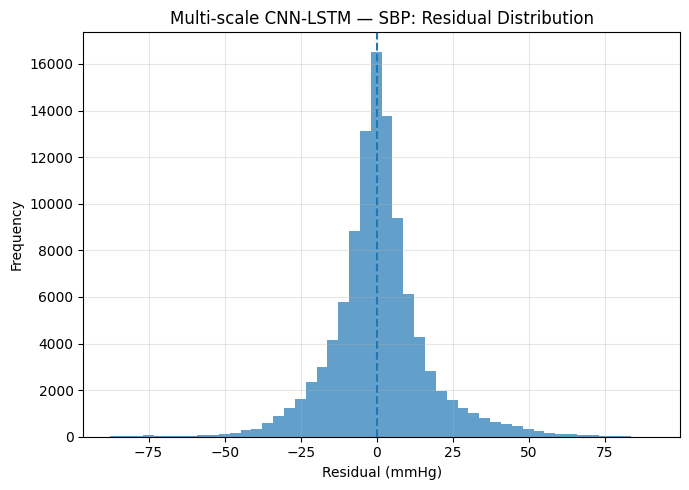

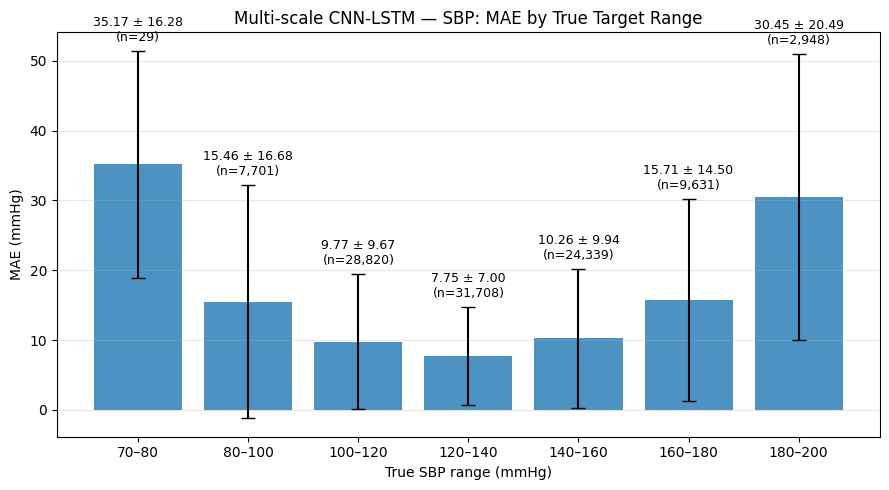

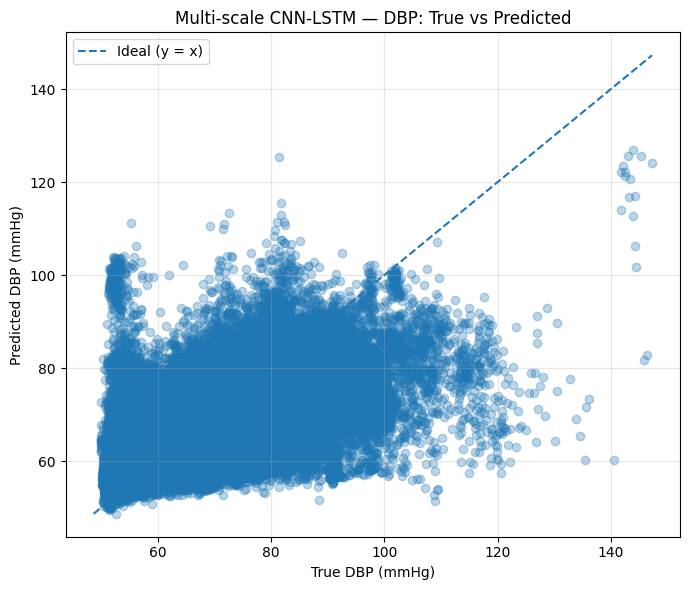

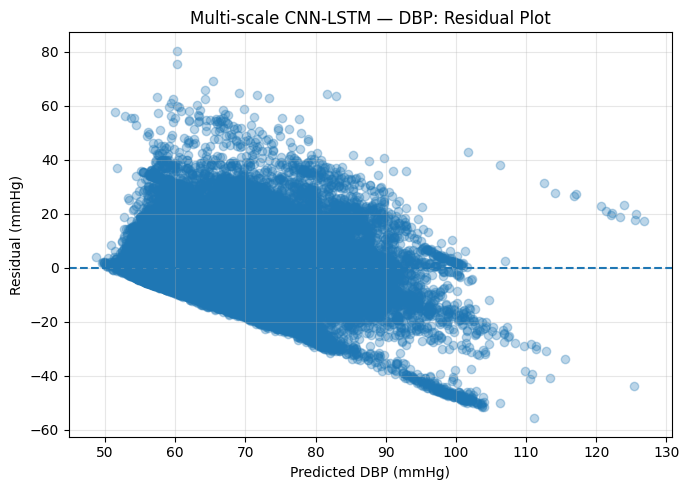

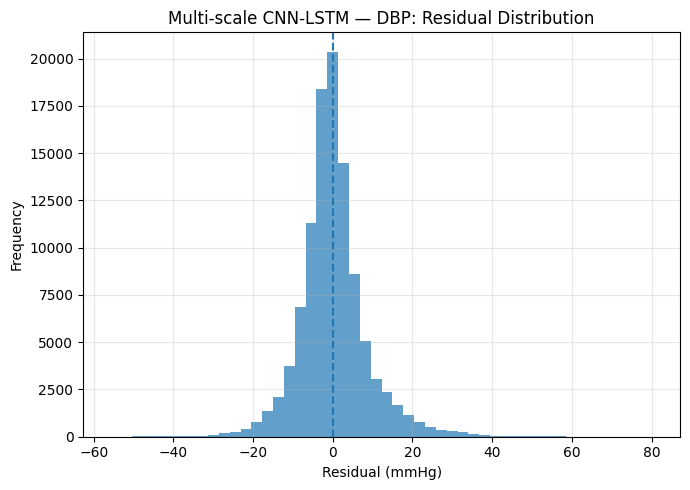

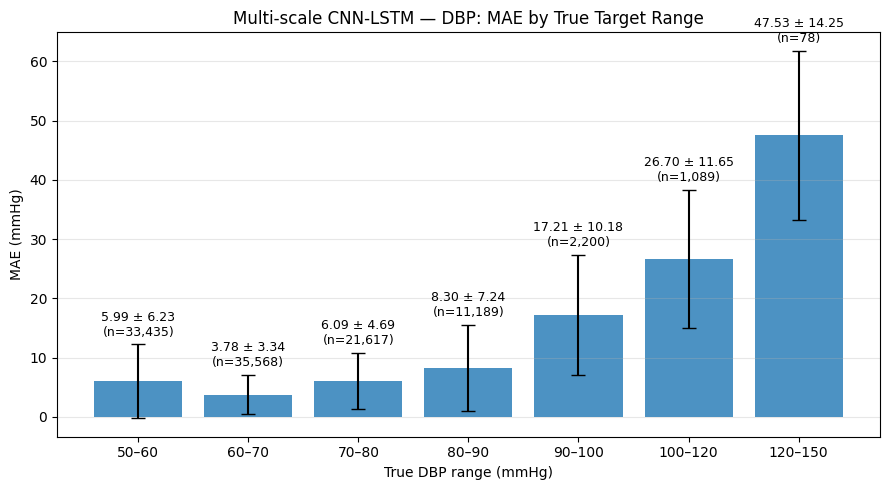

In [15]:
model_multiscale, results_multiscale = train_multiscale_cnn_lstm( 
    X_train=X_train, 
    y_train=y_train, 
    X_val=X_val, 
    y_val=y_val, 
    X_test=X_test,
     y_test=y_test, 
     batch_size=256, 
     epochs=50, 
     lr=1e-3, 
     patience=10 )


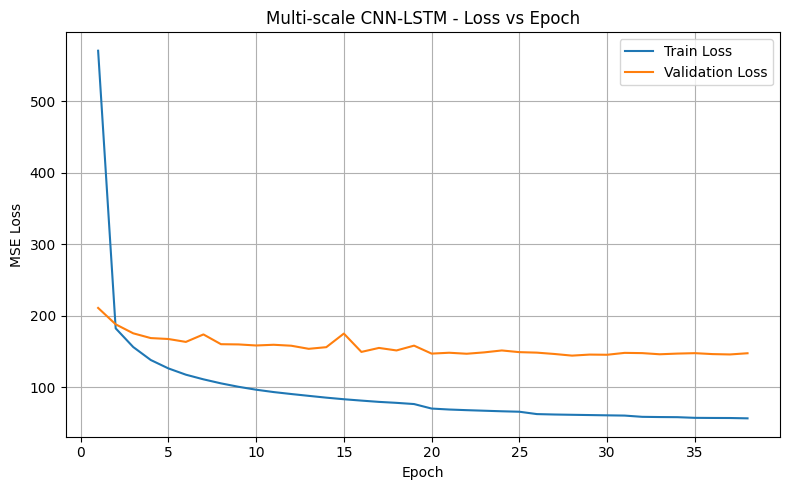

In [16]:
plot_loss_vs_epoch( results_multiscale["history"], model_name="Multi-scale CNN-LSTM" )

Number of VitalDB cases: 1963


CNN-LSTM VitalDB prediction: 100%|██████████| 1963/1963 [06:11<00:00,  5.29case/s]



CNN-LSTM
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 26.5804
MSE : 706.5167
R²  : -0.6530
MAE : 20.9679

DBP
RMSE: 15.2442
MSE : 232.3844
R²  : -0.4308
MAE : 11.9781


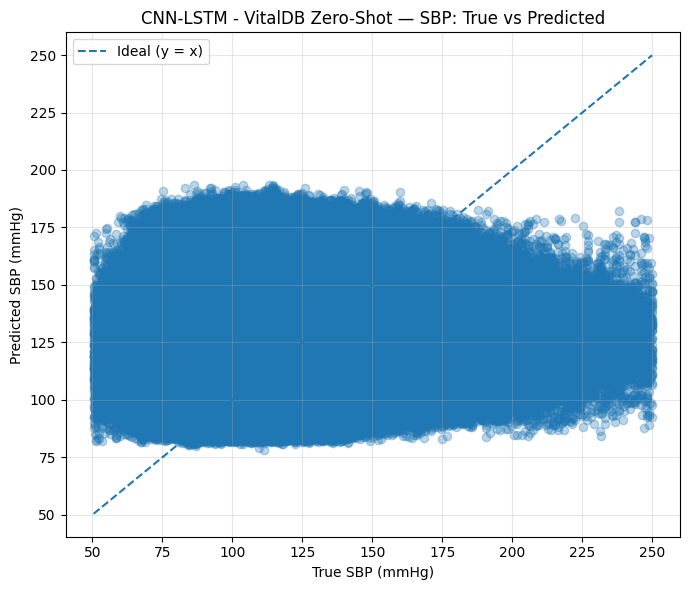

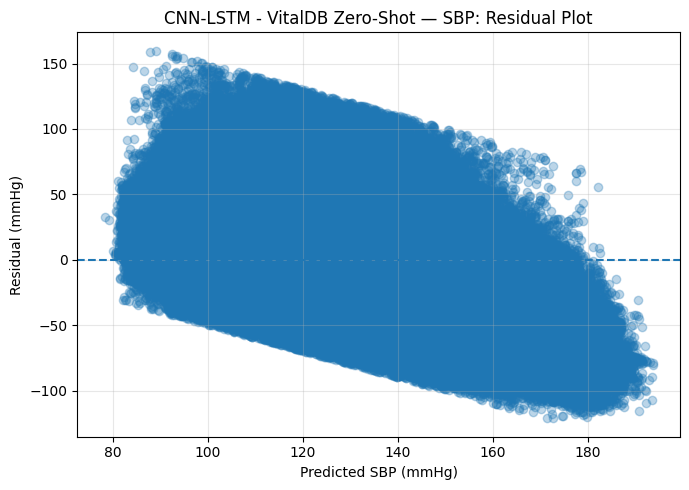

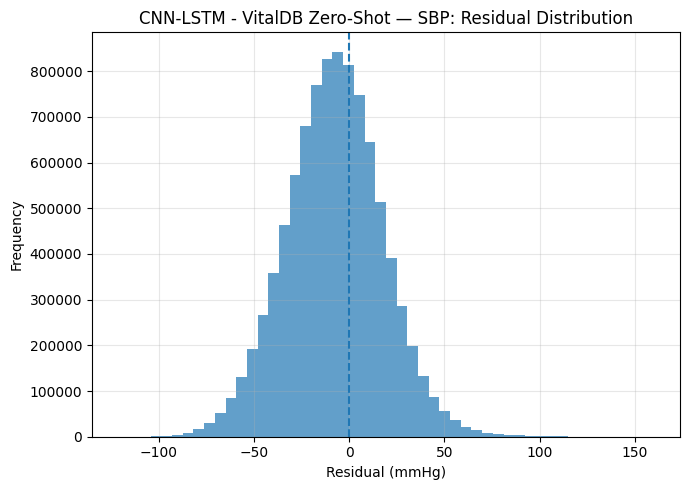

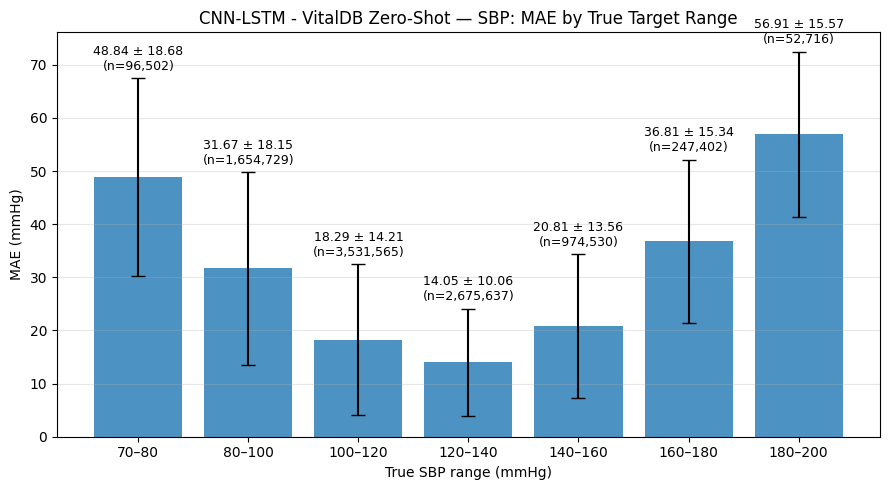

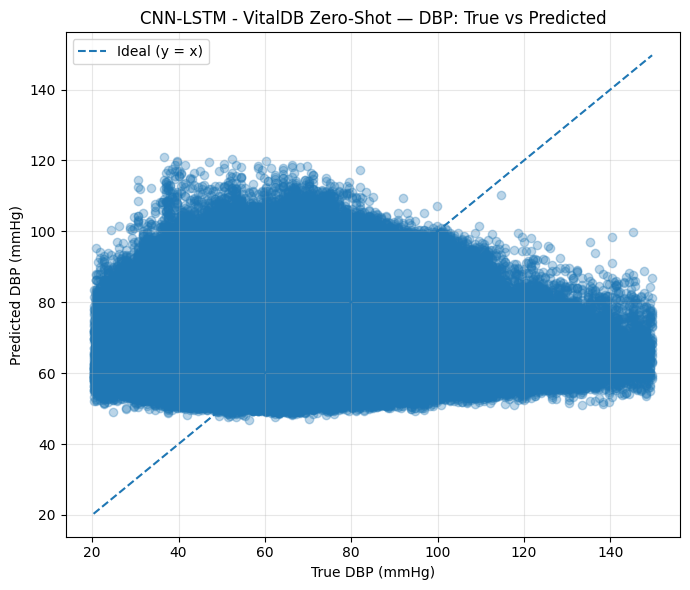

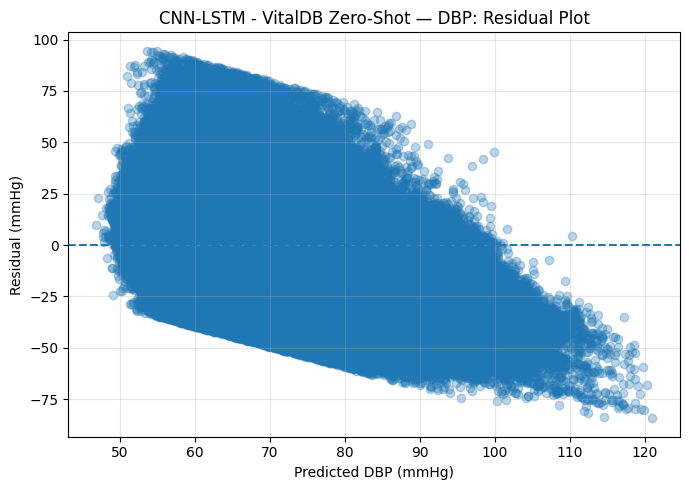

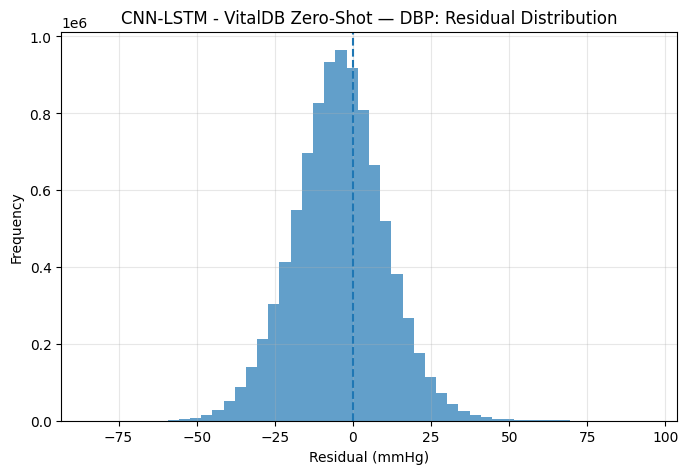

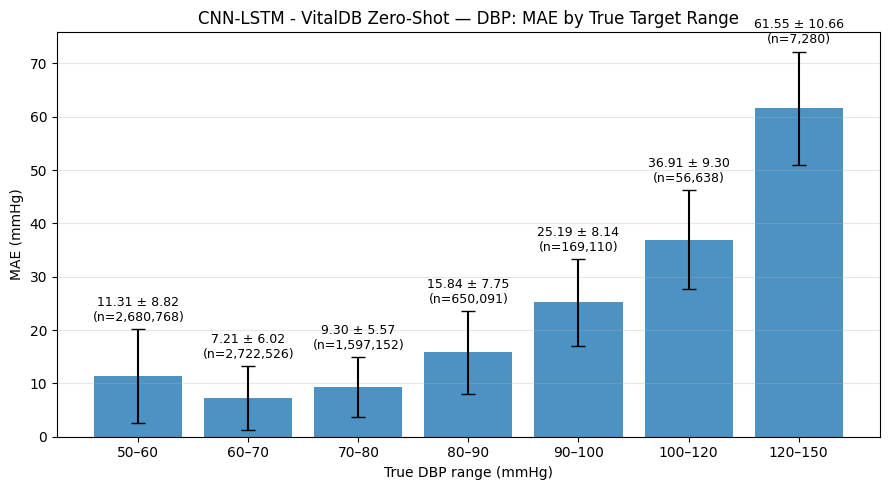

In [17]:
results_multiscale_vitaldb = evaluate_cnn_lstm_vitaldb( model=model_multiscale, base_dir=BASE_DIR, batch_size=256 )

####

In [18]:
model_attention, results_attention = train_cnn_lstm_attention(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    batch_size=256,
    epochs=50,
    lr=1e-3,
    patience=10
)

Epoch 01/50 | Train Loss: 584.0519 | Val Loss: 675.9689 | Train RMSE SBP/DBP: 30.62/15.17 | Val RMSE SBP/DBP: 31.65/18.71
Epoch 02/50 | Train Loss: 184.5818 | Val Loss: 823.0943 | Train RMSE SBP/DBP: 16.42/9.98 | Val RMSE SBP/DBP: 35.28/20.04
Epoch 03/50 | Train Loss: 151.7847 | Val Loss: 868.3940 | Train RMSE SBP/DBP: 14.75/9.28 | Val RMSE SBP/DBP: 36.75/19.66
Epoch 04/50 | Train Loss: 132.6887 | Val Loss: 895.1028 | Train RMSE SBP/DBP: 13.77/8.70 | Val RMSE SBP/DBP: 37.41/19.76
Epoch 05/50 | Train Loss: 120.1198 | Val Loss: 851.6814 | Train RMSE SBP/DBP: 13.08/8.31 | Val RMSE SBP/DBP: 36.27/19.69
Epoch 06/50 | Train Loss: 106.5914 | Val Loss: 917.6178 | Train RMSE SBP/DBP: 12.23/7.97 | Val RMSE SBP/DBP: 38.10/19.58
Epoch 07/50 | Train Loss: 102.3500 | Val Loss: 871.8263 | Train RMSE SBP/DBP: 11.98/7.83 | Val RMSE SBP/DBP: 37.52/18.32
Epoch 08/50 | Train Loss: 98.4389 | Val Loss: 839.3687 | Train RMSE SBP/DBP: 11.74/7.68 | Val RMSE SBP/DBP: 36.24/19.12
Epoch 09/50 | Train Loss: 95.438

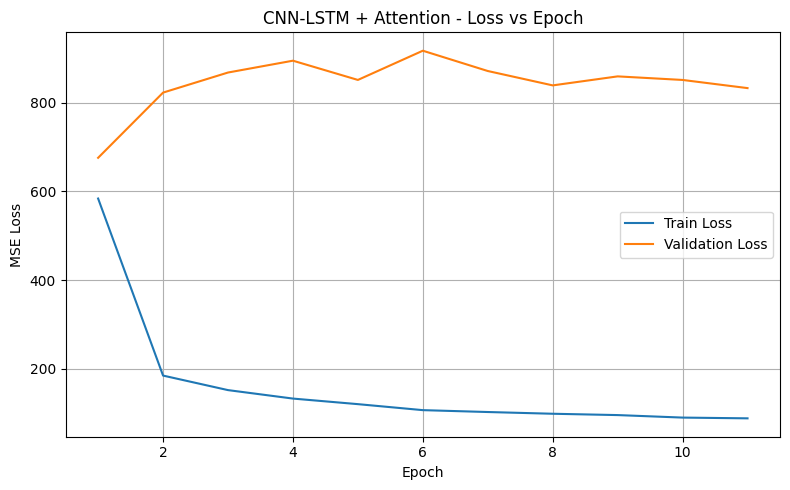

In [19]:
plot_loss_vs_epoch(
    results_attention["history"],
    model_name="CNN-LSTM + Attention"
)

Number of VitalDB cases: 1963


CNN-LSTM VitalDB prediction: 100%|██████████| 1963/1963 [04:46<00:00,  6.85case/s]



CNN-LSTM
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 26.2182
MSE : 687.3936
R²  : -0.6083
MAE : 20.6469

DBP
RMSE: 17.2514
MSE : 297.6124
R²  : -0.8324
MAE : 13.7626


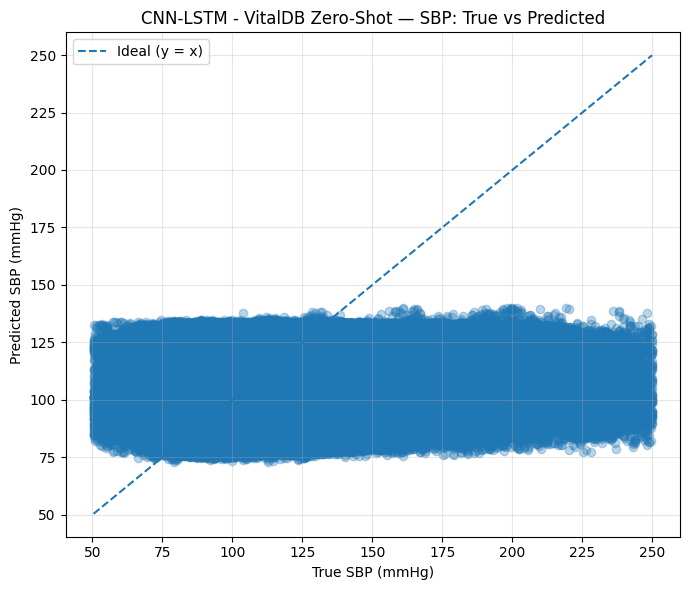

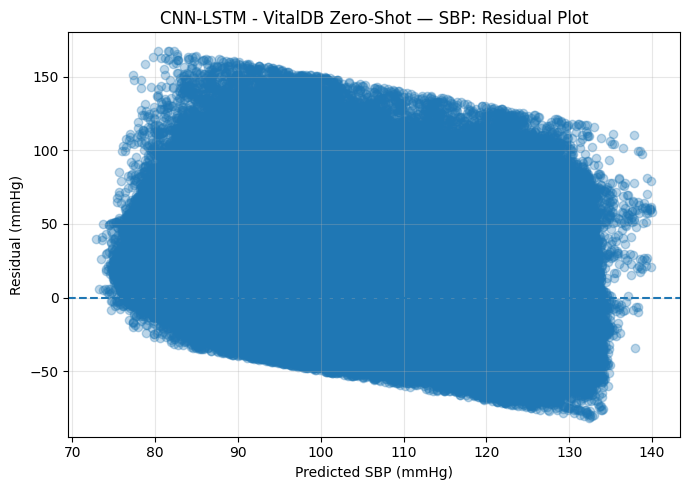

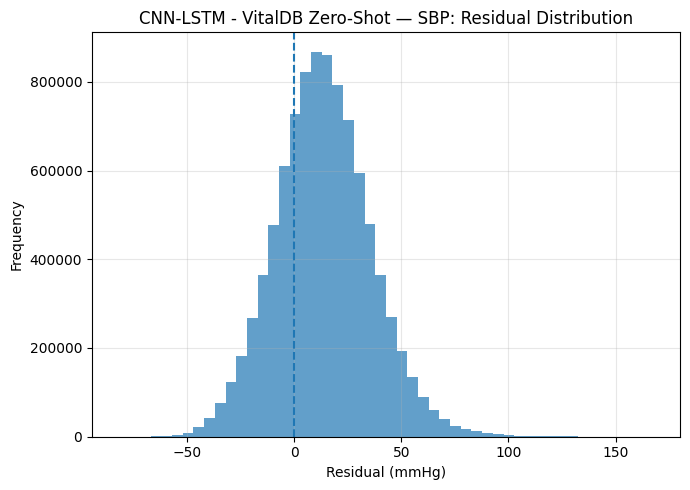

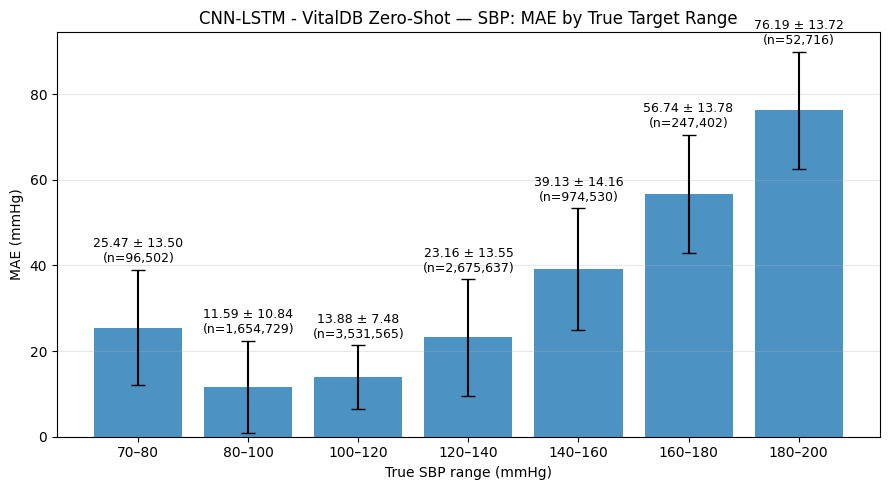

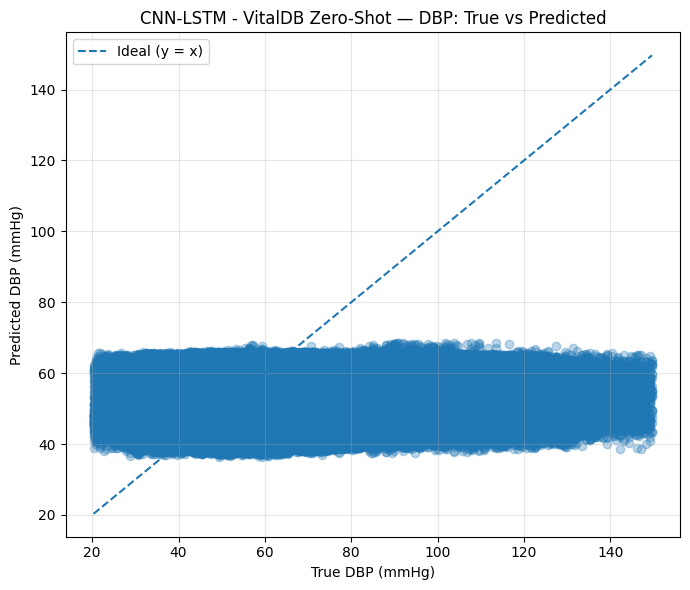

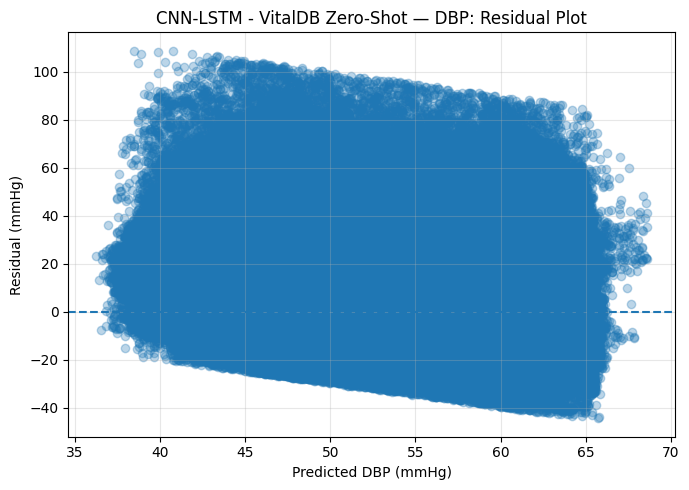

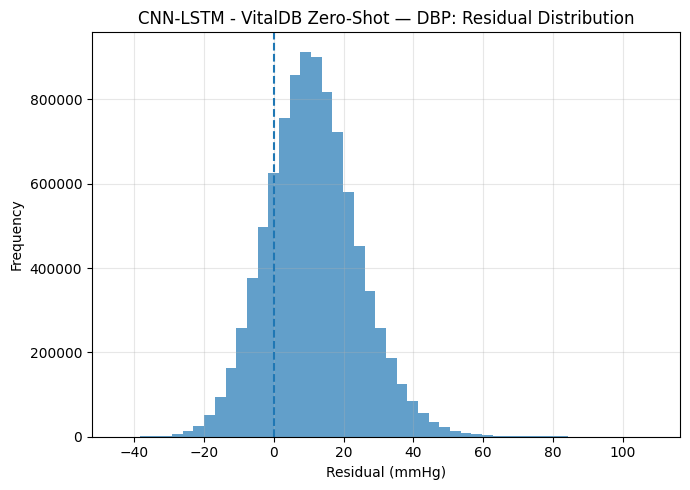

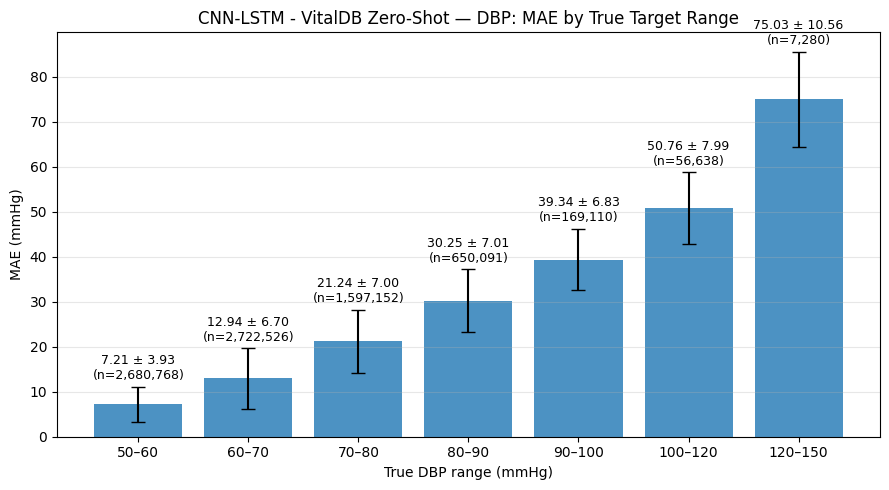

In [20]:

results_attention_vitaldb = evaluate_cnn_lstm_vitaldb(
    model=model_attention,
    base_dir=BASE_DIR,
    batch_size=256
)